In [5]:
import os

DATASET_PATH = "dataset/PCB_DATASET"

# --- 1. File System Overview ---
print(f"\n[SECTION 1] Directory Inspection: {DATASET_PATH}")
print("-" * 40)
count = 0
for root, dirs, files in os.walk(DATASET_PATH):
    for file in files:
        # if count < 10:  # Show first 10 files as examples
        #     print(f"Found: {os.path.join(root, file)}")
        #     count += 1
        print(f"Found: {os.path.join(root, file)}")
if count == 0:
    print("Warning: No files found. Please check your path.")


[SECTION 1] Directory Inspection: dataset/PCB_DATASET
----------------------------------------
Found: dataset/PCB_DATASET\rotate.py
Found: dataset/PCB_DATASET\Annotations\Missing_hole\01_missing_hole_01.xml
Found: dataset/PCB_DATASET\Annotations\Missing_hole\01_missing_hole_02.xml
Found: dataset/PCB_DATASET\Annotations\Missing_hole\01_missing_hole_03.xml
Found: dataset/PCB_DATASET\Annotations\Missing_hole\01_missing_hole_04.xml
Found: dataset/PCB_DATASET\Annotations\Missing_hole\01_missing_hole_05.xml
Found: dataset/PCB_DATASET\Annotations\Missing_hole\01_missing_hole_06.xml
Found: dataset/PCB_DATASET\Annotations\Missing_hole\01_missing_hole_07.xml
Found: dataset/PCB_DATASET\Annotations\Missing_hole\01_missing_hole_08.xml
Found: dataset/PCB_DATASET\Annotations\Missing_hole\01_missing_hole_09.xml
Found: dataset/PCB_DATASET\Annotations\Missing_hole\01_missing_hole_10.xml
Found: dataset/PCB_DATASET\Annotations\Missing_hole\01_missing_hole_11.xml
Found: dataset/PCB_DATASET\Annotations\Mis

## Import & Parameter

In [12]:
import os
import cv2
import numpy as np
import pandas as pd
import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt

# Ensure scikit-image is available for SSIM-NET simulation
try:
    from skimage.metrics import structural_similarity as ssim
except ImportError:
    # Fallback message to assist in setting up the environment
    raise ImportError("Please install scikit-image using: pip install scikit-image")

# Set up global parameters for comparison algorithm input requirements
TARGET_SIZE = (224, 224) # Standard input size for LPViT, ResNet, MobileNet, and AlexNet
PIXELS_PER_MM = 15.0     # Default spatial calibration factor

print("✅ Initialization complete. Target patch dimension set to:", TARGET_SIZE)

✅ Initialization complete. Target patch dimension set to: (224, 224)


## Preprocessing Module

In [13]:
def denoise_image(image, method='gaussian', ksize=5):
    """
    Apply spatial filtering to reduce high-frequency noise from optical capture.
    """
    if method == 'gaussian':
        return cv2.GaussianBlur(image, (ksize, ksize), 0)
    elif method == 'median':
        return cv2.medianBlur(image, ksize)
    return image

def enhance_contrast_clahe(image):
    """
    Apply CLAHE (Contrast Limited Adaptive Histogram Equalization).
    Highly effective for distinguishing copper traces from PCB substrate under varying lighting.
    """
    if len(image.shape) == 3:
        # Convert to LAB color space to apply CLAHE to the L (luminance) channel
        lab = cv2.cvtColor(image, cv2.COLOR_BGR2LAB)
        l, a, b = cv2.split(lab)
        clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
        cl = clahe.apply(l)
        enhanced_lab = cv2.merge((cl, a, b))
        return cv2.cvtColor(enhanced_lab, cv2.COLOR_LAB2BGR)
    else:
        clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
        return clahe.apply(image)

def binarize_image(image, block_size=11, c_val=2):
    """
    Convert image to binary (black and white).
    Essential preprocessing step for the Auto-VRS XOR difference pipeline.
    """
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY) if len(image.shape) == 3 else image
    # Use adaptive thresholding to account for uneven illumination across the board
    binary = cv2.adaptiveThreshold(
        gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
        cv2.THRESH_BINARY, block_size, c_val
    )
    return binary

print("✅ Preprocessing functions loaded.")

✅ Preprocessing functions loaded.


## Image Calibration & Rectification Module

In [14]:
class PCBCalibrator:
    def __init__(self, pixels_per_mm=15.0):
        self.pixels_per_mm = pixels_per_mm

    def pixel_to_physical(self, pixel_val):
        """Converts pixel distance to physical measurements (mm)"""
        return pixel_val / self.pixels_per_mm

    def rectify_and_align(self, src_img, ref_img):
        """
        Detects ORB features to align and warp the target image to match 
        the geometry of the template reference image.
        """
        # Convert both images to grayscale for keypoint detection
        gray_src = cv2.cvtColor(src_img, cv2.COLOR_BGR2GRAY) if len(src_img.shape) == 3 else src_img
        gray_ref = cv2.cvtColor(ref_img, cv2.COLOR_BGR2GRAY) if len(ref_img.shape) == 3 else ref_img

        # Initialize ORB detector
        orb = cv2.ORB_create(nfeatures=5000)
        kp1, des1 = orb.detectAndCompute(gray_src, None)
        kp2, des2 = orb.detectAndCompute(gray_ref, None)

        if des1 is None or des2 is None:
            # Fallback if feature descriptors cannot be established
            return src_img

        # Perform brute-force Hamming match
        bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
        matches = sorted(bf.match(des1, des2), key=lambda x: x.distance)

        # Select top-tier matches
        good_matches = matches[:120]
        src_pts = np.float32([kp1[m.queryIdx].pt for m in good_matches]).reshape(-1, 1, 2)
        ref_pts = np.float32([kp2[m.trainIdx].pt for m in good_matches]).reshape(-1, 1, 2)

        # Calculate Perspective Homography Matrix and warp the source image
        H, mask = cv2.findHomography(src_pts, ref_pts, cv2.RANSAC, 5.0)
        height, width = ref_img.shape[:2]
        rectified_image = cv2.warpPerspective(src_img, H, (width, height))
        
        return rectified_image

print("✅ Calibration and spatial rectification module loaded.")

✅ Calibration and spatial rectification module loaded.


In [ ]:
## Detection & Patch Extraction for the 4 Algorithm

In [15]:
class PCBCalibrator:
    def __init__(self, pixels_per_mm=15.0):
        self.pixels_per_mm = pixels_per_mm

    def pixel_to_physical(self, pixel_val):
        """Converts pixel distance to physical measurements (mm)"""
        return pixel_val / self.pixels_per_mm

    def rectify_and_align(self, src_img, ref_img):
        """
        Detects ORB features to align and warp the target image to match 
        the geometry of the template reference image.
        """
        # Convert both images to grayscale for keypoint detection
        gray_src = cv2.cvtColor(src_img, cv2.COLOR_BGR2GRAY) if len(src_img.shape) == 3 else src_img
        gray_ref = cv2.cvtColor(ref_img, cv2.COLOR_BGR2GRAY) if len(ref_img.shape) == 3 else ref_img

        # Initialize ORB detector
        orb = cv2.ORB_create(nfeatures=5000)
        kp1, des1 = orb.detectAndCompute(gray_src, None)
        kp2, des2 = orb.detectAndCompute(gray_ref, None)

        if des1 is None or des2 is None:
            # Fallback if feature descriptors cannot be established
            return src_img

        # Perform brute-force Hamming match
        bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
        matches = sorted(bf.match(des1, des2), key=lambda x: x.distance)

        # Select top-tier matches
        good_matches = matches[:120]
        src_pts = np.float32([kp1[m.queryIdx].pt for m in good_matches]).reshape(-1, 1, 2)
        ref_pts = np.float32([kp2[m.trainIdx].pt for m in good_matches]).reshape(-1, 1, 2)

        # Calculate Perspective Homography Matrix and warp the source image
        H, mask = cv2.findHomography(src_pts, ref_pts, cv2.RANSAC, 5.0)
        height, width = ref_img.shape[:2]
        rectified_image = cv2.warpPerspective(src_img, H, (width, height))
        
        return rectified_image

print("✅ Calibration and spatial rectification module loaded.")

✅ Calibration and spatial rectification module loaded.


In [17]:
# ==============================================================================
# MISSING CELL: PATCH & ROI EXTRACTION MODULE FOR THE 4 ALGORITHMS
# ==============================================================================

def extract_ground_truth_patches(image, xml_path, target_size=TARGET_SIZE):
    """
    Pipeline 1: Supervised Ground-Truth Extraction (for LPViT & CS-ResNet).
    Parses the XML annotations and crops patches of exact defect zones, 
    resizing them to 224x224 to feed directly into deep learning networks.
    """
    if not os.path.exists(xml_path):
        return []
    
    tree = ET.parse(xml_path)
    root = tree.getroot()
    patches = []
    
    for obj in root.findall('object'):
        name = obj.find('name').text
        bndbox = obj.find('bndbox')
        xmin = int(float(bndbox.find('xmin').text))
        ymin = int(float(bndbox.find('ymin').text))
        xmax = int(float(bndbox.find('xmax').text))
        ymax = int(float(bndbox.find('ymax').text))
        
        # Ensure bounding box coordinates are within image boundaries
        h, w = image.shape[:2]
        xmin, ymin = max(0, xmin), max(0, ymin)
        xmax, ymax = min(w, xmax), min(h, ymax)
        
        # Crop and resize
        crop = image[ymin:ymax, xmin:xmax]
        if crop.size > 0:
            resized_patch = cv2.resize(crop, target_size)
            patches.append({"class": name, "patch": resized_patch, "coords": (xmin, ymin, xmax, ymax)})
            
    return patches

def extract_ssim_net_rois(rectified_img, ref_img, ssim_threshold=0.6, target_size=TARGET_SIZE):
    """
    Pipeline 2: SSIM-NET Pre-localization (for MobileNetV3 input).
    Calculates structural similarity mapping between target and template.
    Locates degraded structural areas, filters out noise, and crops patches 
    of structural anomalies as inputs for MobileNetV3.
    """
    # SSIM requires grayscale inputs
    gray_rect = cv2.cvtColor(rectified_img, cv2.COLOR_BGR2GRAY) if len(rectified_img.shape) == 3 else rectified_img
    gray_ref = cv2.cvtColor(ref_img, cv2.COLOR_BGR2GRAY) if len(ref_img.shape) == 3 else ref_img
    
    # Calculate SSIM full map
    score, diff_map = ssim(gray_rect, gray_ref, full=True)
    
    # Convert similarity mapping to a difference mask
    diff_map = (diff_map * 255).astype("uint8")
    _, thresh = cv2.threshold(diff_map, int(ssim_threshold * 255), 255, cv2.THRESH_BINARY_INV)
    
    # Locate contours of highly dissimilar structures
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    rois = []
    
    for ctr in contours:
        # Ignore minute noise perturbations using area constraint
        if cv2.contourArea(ctr) > 80:
            x, y, w, h = cv2.boundingRect(ctr)
            crop = rectified_img[y:y+h, x:x+w]
            if crop.size > 0:
                resized_patch = cv2.resize(crop, target_size)
                rois.append({"patch": resized_patch, "coords": (x, y, x + w, y + h)})
                
    return rois

def extract_auto_vrs_rois(rectified_img, ref_img, min_area=50, target_size=TARGET_SIZE):
    """
    Pipeline 3: Auto-VRS XOR Difference (for AlexNet input).
    Performs binarization, executes a bitwise XOR to highlight geometric deviation,
    and isolates structural changes as candidates for AlexNet pseudo-defect verification.
    """
    # 1. Binarize both template and target
    bin_rect = binarize_image(rectified_img)
    bin_ref = binarize_image(ref_img)
    
    # 2. Execute Microsecond-level Logical XOR Difference
    xor_diff = cv2.bitwise_xor(bin_rect, bin_ref)
    
    # 3. Clean noise and close gap structures
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
    clean_diff = cv2.morphologyEx(xor_diff, cv2.MORPH_CLOSE, kernel)
    
    # 4. Extract contours of geometric differences
    contours, _ = cv2.findContours(clean_diff, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    rois = []
    
    for ctr in contours:
        if cv2.contourArea(ctr) > min_area:
            x, y, w, h = cv2.boundingRect(ctr)
            crop = rectified_img[y:y+h, x:x+w]
            if crop.size > 0:
                resized_patch = cv2.resize(crop, target_size)
                rois.append({"patch": resized_patch, "coords": (x, y, x + w, y + h)})
                
    return rois

print("✅ Bounding box and patch generators successfully built.")

✅ Bounding box and patch generators successfully built.


## Pipeline Execution & Comparative Visualization

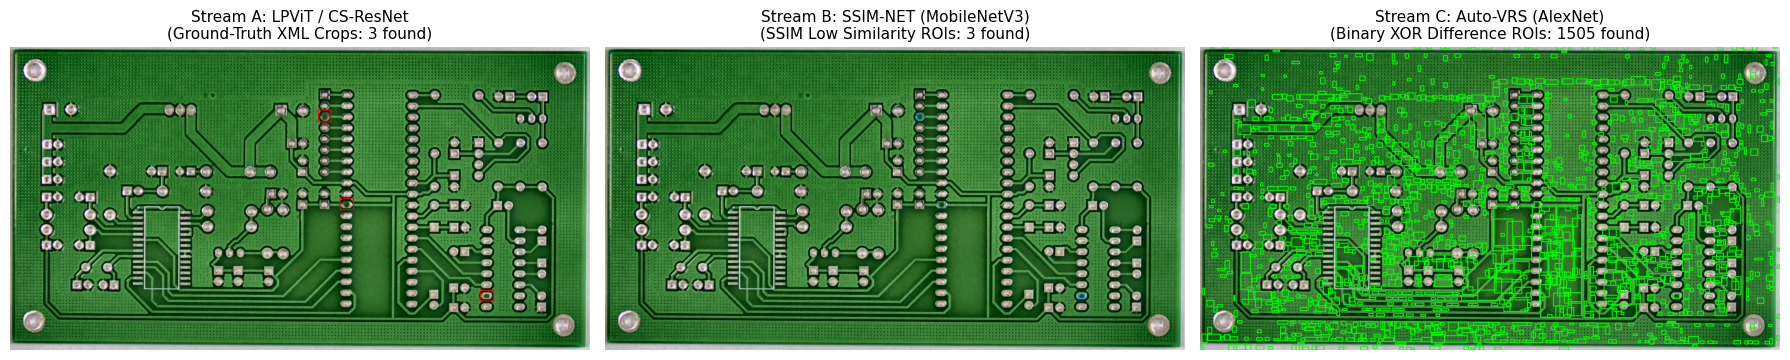

📊 Patch generation summary ready for comparison models:
   -> LPViT/ResNet patch dimensions: (224, 224, 3) (Ready for network train/val)
   -> MobileNetV3 patch dimensions: (224, 224, 3) (Ready for inference evaluation)
   -> AlexNet patch dimensions: (224, 224, 3) (Ready for pseudo-defect sorting)


In [18]:
# Configure paths to matching PCB pairs from your dataset
# (Using the DATASET_PATH variable defined in your directory inspection)
DATASET_PATH = "dataset/PCB_DATASET"

TEST_TARGET_PATH = os.path.join(DATASET_PATH, "images/Missing_hole/01_missing_hole_01.jpg")
TEST_TEMPLATE_PATH = os.path.join(DATASET_PATH, "PCB_USED/01.JPG")
TEST_XML_PATH = os.path.join(DATASET_PATH, "Annotations/Missing_hole/01_missing_hole_01.xml")

# Verify sample availability
if not os.path.exists(TEST_TARGET_PATH) or not os.path.exists(TEST_TEMPLATE_PATH):
    print(f"⚠️ Please verify that dataset paths match your folder structure.")
    print(f"Looked for target at: {TEST_TARGET_PATH}")
    print(f"Looked for template at: {TEST_TEMPLATE_PATH}")
else:
    # 1. Read Raw Images
    raw_target = cv2.imread(TEST_TARGET_PATH)
    raw_template = cv2.imread(TEST_TEMPLATE_PATH)
    
    # 2. Execute Preprocessing & Calibration (functions defined in preceding cells)
    preprocessed_target = enhance_contrast_clahe(denoise_image(raw_target, 'gaussian', 5))
    preprocessed_template = enhance_contrast_clahe(denoise_image(raw_template, 'gaussian', 5))
    
    calibrator = PCBCalibrator(pixels_per_mm=PIXELS_PER_MM)
    aligned_target = calibrator.rectify_and_align(preprocessed_target, preprocessed_template)
    
    # 3. Extract Patches for Comparative Algorithms
    # Stream A: LPViT / CS-ResNet Ground Truth crops
    gt_patches = extract_ground_truth_patches(aligned_target, TEST_XML_PATH)
    
    # Stream B: SSIM-NET (MobileNetV3 inputs)
    ssim_rois = extract_ssim_net_rois(aligned_target, preprocessed_template, ssim_threshold=0.7)
    
    # Stream C: Auto-VRS (AlexNet input candidates via XOR)
    xor_rois = extract_auto_vrs_rois(aligned_target, preprocessed_template)
    
    # 4. Generate Comparative Visualizations
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    # Frame 1: LPViT / CS-ResNet Visual Verification
    annotated_a = aligned_target.copy()
    for patch in gt_patches:
        x1, y1, x2, y2 = patch["coords"]
        cv2.rectangle(annotated_a, (x1, y1), (x2, y2), (0, 0, 255), 4)
    axes[0].imshow(cv2.cvtColor(annotated_a, cv2.COLOR_BGR2RGB))
    axes[0].set_title(f"Stream A: LPViT / CS-ResNet\n(Ground-Truth XML Crops: {len(gt_patches)} found)", fontsize=11)
    axes[0].axis('off')
    
    # Frame 2: SSIM-NET (MobileNetV3) Visual Verification
    annotated_b = aligned_target.copy()
    for roi in ssim_rois:
        x1, y1, x2, y2 = roi["coords"]
        cv2.rectangle(annotated_b, (x1, y1), (x2, y2), (255, 165, 0), 4)
    axes[1].imshow(cv2.cvtColor(annotated_b, cv2.COLOR_BGR2RGB))
    axes[1].set_title(f"Stream B: SSIM-NET (MobileNetV3)\n(SSIM Low Similarity ROIs: {len(ssim_rois)} found)", fontsize=11)
    axes[1].axis('off')
    
    # Frame 3: Auto-VRS (AlexNet) Visual Verification
    annotated_c = aligned_target.copy()
    for roi in xor_rois:
        x1, y1, x2, y2 = roi["coords"]
        cv2.rectangle(annotated_c, (x1, y1), (x2, y2), (0, 255, 0), 4)
    axes[2].imshow(cv2.cvtColor(annotated_c, cv2.COLOR_BGR2RGB))
    axes[2].set_title(f"Stream C: Auto-VRS (AlexNet)\n(Binary XOR Difference ROIs: {len(xor_rois)} found)", fontsize=11)
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # Output metrics verifying input sizes
    print(f"📊 Patch generation summary ready for comparison models:")
    if gt_patches:
        print(f"   -> LPViT/ResNet patch dimensions: {gt_patches[0]['patch'].shape} (Ready for network train/val)")
    if ssim_rois:
        print(f"   -> MobileNetV3 patch dimensions: {ssim_rois[0]['patch'].shape} (Ready for inference evaluation)")
    if xor_rois:
        print(f"   -> AlexNet patch dimensions: {xor_rois[0]['patch'].shape} (Ready for pseudo-defect sorting)")

--算法流	这一步在做什么？	为什么必须做？
- Stream A: LPViT / CS-ResNet	利用 XML 标注（Ground Truth）精准切片。	训练需要。用于训练和验证这两个重型深度分类器，让它们在 224×224 的标准视野下，榨干模型分类精度的极限。
- Stream B: MobileNetV3 (SSIM-NET)	模拟“SSIM 粗定位 -> 极轻量网络精分类”的混合流程。	模拟推理。产线运行时没有 XML。必须先用 SSIM 快速筛出可能有缺陷的 224×224 区域，再 MobileNetV3 做毫秒级分类。
- Stream C: AlexNet (Auto-VRS)	模拟“XOR 异或差分 -> CNN 滤除伪缺陷”流程。	模拟推理。利用 XOR 差分快速抠出有差异的 224×224
 局部方块，送给 AlexNet 判断这到底是真缺陷，还是光影引起的“伪缺陷”。

## Batch dataset generation and train/val partitioning

--1. 自动创建标准的深度学习数据集目录（Dataset Structuring）
深度学习框架（如 PyTorch 的 torchvision.datasets.ImageFolder）要求训练数据必须排布成特定的文件夹格式。
这个脚本首先在您的本地创建了如下结构：
创建 train/（训练集）和 val/（验证集）两个主目录。
在每个主目录下，自动创建了 6 个以缺陷命名的子文件夹（如 Missing_hole、Mouse_bite 等），文件夹的名称就是模型后续训练时的分类标签（Class Labels）。
2. 自动化寻找标准模板图并进行几何对齐（Template Matching & Homography）
PKU PCB 数据集的命名规则是：
缺陷大图：images/Missing_hole/01_missing_hole_01.jpg
对应的无缺陷模板图：PCB_USED/01.JPG
脚本会自动提取文件名最前方的数字前缀（如 01），在 PCB_USED 目录中匹配到正确的标准模板，并调用 ORB 特征对齐算法（rectify_and_align），消除由于拍照角度偏转、平移带来的误差，使缺陷大图与模板在空间坐标上完美重合。
3. 解析 XML 标注，精准切割并缩放（Cropping & Resizing）
脚本自动解析对应的 XML 标注文件，读出每个缺陷的真实坐标边界框（Bounding Box）。
顺着边界框把缺陷从对齐后的大图里“抠”出来。
将这些大小不一的抠图统一缩放到 224×224 像素（这是 LPViT、CS-ResNet、MobileNetV3 和 AlexNet 的标准输入尺寸）。
4. 数据集随机打乱与比例划分（Random Splitting）
为了防止模型过拟合，我们需要将数据分成训练集（用来学习规律）和验证集（用来评估效果）。
脚本固定了随机种子（random.seed(42)），确保每次运行划分的结果都一模一样（可重复性）。
按照 80% 训练集、20% 验证集 的比例，将每个类别的图片自动分配到对应的划分中。
5. 将处理好的小图（Patches）序列化保存到本地（Serialization）
裁剪和缩放后的 224×224 图像块会被赋予新名字（例如 01_missing_hole_01_p0.jpg），然后写入硬盘。

-为什么要提前写到硬盘？
- 因为 ORB 图像对齐和 XML 解析是非常消耗 CPU 算力和时间的。如果在 PyTorch 训练时“边训练、边对齐、边裁剪”，GPU 会一直处于“饥饿”状态等待 CPU 处理数据，导致训练极慢。提前生成并保存好这些小图，在训练时只需用极快的速度直接读取即可

In [ ]:
import os
import random
import shutil
import cv2

# --- 1. Configure Input/Output Paths ---
DATASET_PATH = "dataset/PCB_DATASET"
OUTPUT_DIR = "dataset_processed"  # Directory where the standardized classification dataset will be saved
SPLIT_RATIO = 0.8  # 80% for training set, 20% for validation set

# Target class names (corresponds to directory names)
CLASS_NAMES = ["Missing_hole", "Mouse_bite", "Open_circuit", "Short", "Spur", "Spurious_copper"]

# Ensure the output directory is clean/empty before generating new data
if os.path.exists(OUTPUT_DIR):
    shutil.rmtree(OUTPUT_DIR)

# Create output subdirectories for splits
for split in ["train", "val"]:
    for cls in CLASS_NAMES:
        os.makedirs(os.path.join(OUTPUT_DIR, split, cls), exist_ok=True)

# --- 2. Core Batch Extraction Function ---
def batch_generate_dataset():
    print("⏳ Starting batch generation... This may take a moment.")
    
    calibrator = PCBCalibrator(pixels_per_mm=PIXELS_PER_MM)
    total_processed_patches = 0
    
    # Iterate through the 6 defect classes
    for cls in CLASS_NAMES:
        annotations_dir = os.path.join(DATASET_PATH, "Annotations", cls)
        if not os.path.exists(annotations_dir):
            continue
            
        xml_files = [f for f in os.listdir(annotations_dir) if f.endswith('.xml')]
        
        # Shuffle files randomly to facilitate training and validation splitting
        random.seed(42)  # Fix random seed to ensure reproducibility
        random.shuffle(xml_files)
        
        split_idx = int(len(xml_files) * SPLIT_RATIO)
        
        for idx, xml_file in enumerate(xml_files):
            # 1. Parse file name to identify template prefix
            # Example: "01_missing_hole_01.xml" -> template prefix is "01"
            template_prefix = xml_file.split('_')[0]
            
            # Handle image file extension case sensitivity
            # Reference/Template is usually uppercase .JPG, target is lowercase .jpg
            template_img_path = os.path.join(DATASET_PATH, "PCB_USED", f"{template_prefix}.JPG")
            if not os.path.exists(template_img_path):
                template_img_path = os.path.join(DATASET_PATH, "PCB_USED", f"{template_prefix}.jpg")
                
            img_file_name = xml_file.replace('.xml', '.jpg')
            target_img_path = os.path.join(DATASET_PATH, "images", cls, img_file_name)
            xml_path = os.path.join(annotations_dir, xml_file)
            
            # Verify file completeness
            if not os.path.exists(target_img_path) or not os.path.exists(template_img_path):
                print(f"⚠️ Warning: Missing image or template for {xml_file}. Skipping.")
                continue
                
            # 2. Read images and align them
            raw_target = cv2.imread(target_img_path)
            raw_template = cv2.imread(template_img_path)
            
            # Preprocessing and geometric alignment
            prep_target = enhance_contrast_clahe(denoise_image(raw_target, 'gaussian', 5))
            prep_template = enhance_contrast_clahe(denoise_image(raw_template, 'gaussian', 5))
            aligned_target = calibrator.rectify_and_align(prep_target, prep_template)
            
            # 3. Extract defect patches
            patches = extract_ground_truth_patches(aligned_target, xml_path, target_size=TARGET_SIZE)
            
            # 4. Assign the patch to either training or validation set
            target_split = "train" if idx < split_idx else "val"
            
            # 5. Save the generated defect patches
            for p_idx, patch_data in enumerate(patches):
                patch_img = patch_data["patch"]
                # Filename format: {original_filename}_p{defect_index}.jpg
                save_name = f"{xml_file.replace('.xml', '')}_p{p_idx}.jpg"
                save_path = os.path.join(OUTPUT_DIR, target_split, cls, save_name)
                
                # Write to disk
                cv2.imwrite(save_path, patch_img)
                total_processed_patches += 1
                
        print(f"✅ Processed class '{cls}': {len(xml_files)} images parsed.")
        
    print(f"\n🎉 Done! Generated {total_processed_patches} patches in total under folder '{OUTPUT_DIR}'.")

# Run batch processing
batch_generate_dataset()

⏳ Starting batch generation... This may take a moment.
✅ Processed class 'Missing_hole': 115 images parsed.
